In [101]:
import pandas as pd
import numpy as np
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
## 데이터셋, 데이터로더 관련 모듈
from torch.nn.utils.rnn import pad_sequence
## 데이터 길이 맞추기

## 토커나이저, 단어사전 관련 모듈
from torchtext.data.utils import get_tokenizer              ## 토커나이저 인스턴스 추출
from torchtext.vocab import build_vocab_from_iterator       ## 데이터셋에서 단어사전 생성 함수
from nltk.corpus import stopwords                           ## 불용어 데이터셋
import nltk
from nltk.tokenize import word_tokenize

In [102]:
dataDF = pd.read_csv('./dataDF.csv', index_col=0, encoding='utf-8')

In [103]:
texts = dataDF['Dialogue'].tolist()
labels = dataDF['age'].tolist()

In [104]:
### ===> 모듈 로딩
from konlpy.tag import Okt
from torchtext.vocab import build_vocab_from_iterator
import string
### ===> 토큰관련 특별 문자
UNK = '<UNK>'
PAD = '<PAD>'
### 토큰화 인스턴스 생성
tokenizer = Okt()
### ===> 토큰 제너레이터 함수 : 데이터 추출하여 토큰화 


In [105]:
PUNC = string.punctuation
STOPWORDS = [
    # 조사 / 불필요 접속어
    '은', '는', '이', '가', '을', '를', '에', '에서', '으로', '의', '도', '만', '까지', '부터',
    '과', '와', '하고', '보다', '보다도',

    # 보조동사 및 흔한 표현
    '있다', '없다', '되다', '해요', '해', '했어요', '했네', '했지', '하지', '그랬지', '그래요', '같아요',
    
    # 대명사 / 불분명 주어
    '그', '저', '이', '것', '거', '자기', '우리', '너', '나', '누구', '사람', '다', '뭐',

    # 웹체 / 감탄 / 의미 낮은 부사
    '정말', '그냥', '좀', '매우', '많이', '아주', '거의', '조금', '계속', '항상', '진짜',
    
    # 대화 문법 전환
    '그래서', '그런데', '그러니까', '하지만', '그리고', '그러면',

    # 의성어 / 감탄사 / 불필요한 감정어
    '티티', '아가씨', '수고했다', '감사합니다', '고맙다', '고마워서', '선물', '미신이야',

    # 웹 말투
    'ㅋㅋ', 'ㅎㅎ', 'ㅠㅠ', '...', '!!', '??'
]
UNK, PAD  = '<UNK>',  '<PAD>'

In [106]:
def yield_tokens(data):
    for line in data:
        line = ''.join([x for x in line if x not in PUNC])
        yield word_tokenize(line.lower())


In [107]:
VOCAB = build_vocab_from_iterator(yield_tokens(texts), specials=[UNK, PAD])
VOCAB.set_default_index(VOCAB[UNK])

In [108]:
VOCAB.get_itos()[:10]

['<UNK>', '<PAD>', '좀', '안', '왜', '거', '그', '이', '내가', '너']

In [109]:
# def encode_texts(data, vocab):
#     encoded = []
#     for line in data:
#         line = ''.join([c for c in line if c not in PUNC])
#         tokens = word_tokenize(line.lower())
#         token_ids = [vocab[token] for token in tokens]
#         encoded.append(torch.tensor(token_ids, dtype=torch.long))
#     return encoded

In [110]:
tokenizer = Okt()
tokens = [tokenizer.morphs(review) for review in texts]

In [111]:
from gensim.models import Word2Vec


word2vec = Word2Vec(
    sentences=tokens,
    vector_size=128,
    window=5,
    min_count=1,
    sg=1,
    epochs=10,
    max_final_vocab=10000
)

# 2. UNK 토큰 추가
unk_vector = np.random.normal(scale=0.6, size=(word2vec.vector_size,))
word2vec.wv.add_vector("<UNK>", unk_vector)

# 3. 단어 인덱스 매핑
word2index = word2vec.wv.key_to_index
unk_index = word2index["<UNK>"]

# 4. 임베딩 weight → PyTorch 임베딩 레이어
embedding_weights = torch.FloatTensor(word2vec.wv.vectors)
embedding_layer = torch.nn.Embedding.from_pretrained(embedding_weights, freeze=False)

c:\Users\kdt\anaconda3\envs\NLP\lib\site-packages\gensim\models\keyedvectors.py:551: UserWarning: Adding single vectors to a KeyedVectors which grows by one each time can be costly. Consider adding in batches or preallocating to the required size.
  warnings.warn(


In [112]:
word2vec.save("./models/word2vec.model")
word2vec = Word2Vec.load("./models/word2vec.model")

In [113]:
# encoded_sequences = encode_texts(texts, VOCAB)

# padded_sequences = pad_sequence(encoded_sequences, batch_first=True, padding_value=VOCAB["<pad>"])
# labels_tensor = torch.tensor(labels, dtype=torch.long)


In [114]:
len(tokens)

16722

In [115]:
embedding_dim = word2vec.vector_size # 로드된 모델에서 임베딩 차원 가져오기
vector_sequences = []
print("데이터를 벡터 시퀀스로 변환 중...")
for tokens in tokens:
    sequence_vectors = []
    for token in tokens:
        if token in word2vec.wv: # 모델의 어휘집(`.wv`)에 있는지 확인
            sequence_vectors.append(word2vec.wv[token]) # 단어 벡터 조회
        else:
            # OOV(Out-Of-Vocabulary) 단어 처리 (예: 0 벡터 사용)
            # print(f"Warning: OOV 단어 '{token}' 발견. 0 벡터로 대체합니다.") # OOV 로깅 (선택 사항)
            sequence_vectors.append(np.zeros(embedding_dim, dtype=np.float32))

    # 각 시퀀스를 FloatTensor로 변환하여 리스트에 추가
    if sequence_vectors:
        vector_sequences.append(torch.tensor(np.array(sequence_vectors), dtype=torch.float))
    else:
        print(f"Warning: 빈 시퀀스 발견 (토큰: {tokens}).")

print(f"변환된 시퀀스 개수: {len(vector_sequences)}")
if not vector_sequences:
    print("오류: 변환된 벡터 시퀀스가 없습니다. 입력 데이터나 Word2Vec 모델을 확인하세요.")
    exit()

데이터를 벡터 시퀀스로 변환 중...
변환된 시퀀스 개수: 16722


In [116]:
padded_sequences = pad_sequence(vector_sequences,
                                batch_first=True,
                                padding_value=0.0)
print(f"패딩된 시퀀스 텐서 모양: {padded_sequences.shape}")

# 3단계: 레이블 텐서 변환
labels_tensor = torch.tensor(labels, dtype=torch.long)
print(f"레이블 텐서 모양: {labels_tensor.shape}")

패딩된 시퀀스 텐서 모양: torch.Size([16722, 176, 128])
레이블 텐서 모양: torch.Size([16722])


In [117]:
# 4단계: 입력 텐서와 레이블 텐서의 첫 번째 차원(샘플 수) 일치 확인
if padded_sequences.shape[0] != labels_tensor.shape[0]:
    print(f"오류: 시퀀스 텐서 샘플 수({padded_sequences.shape[0]})와 "
          f"레이블 텐서 샘플 수({labels_tensor.shape[0]}) 불일치.")
    exit()
else:
    num_samples = padded_sequences.shape[0]
    print(f"총 샘플 수: {num_samples}")

총 샘플 수: 16722


In [118]:
class customDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

In [119]:
from sklearn.model_selection import train_test_split

In [120]:
X_train, X_temp, y_train, y_temp = train_test_split(
    padded_sequences, labels_tensor, test_size=0.2, random_state=42, stratify=labels_tensor
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)
y_test = le.transform(y_test)

train_dataset = customDataset(X_train, y_train)
val_dataset = customDataset(X_val, y_val)
test_dataset = customDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=100, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)

In [121]:
len(train_dataset)

13377

In [122]:
train_dataset[0]
    

(tensor([[-0.1094, -0.1559, -0.0845,  ..., -0.3824, -0.2999, -0.1589],
         [-0.5019, -0.3140, -0.3036,  ..., -0.0929, -0.4375, -0.0232],
         [-0.0843, -0.1010, -0.0210,  ..., -0.0840, -0.0790,  0.0399],
         ...,
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]),
 1)

In [123]:
import torch.optim as optim 
from torch.optim.lr_scheduler import StepLR

In [124]:
# ## -------------------------------------------------------------------------
# ## 클래스이름 : TextModel
# ## 부모클래스 : Module
# ## 매개변수둘 : 단어사전 갯수, 임베딩 수, 2진분류
# ## -------------------------------------------------------------------------
# class TextDnnEmbModel(nn.Module):
#     def __init__(self, vocab_size, embedding_dim=256, hidden_dim=4):
#         super().__init__()
#         self.embedding_layer = nn.Embedding(vocab_size, embedding_dim)
        
#         self.classifier = nn.Sequential(
#             nn.Linear(embedding_dim, hidden_dim),
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.Linear(hidden_dim, hidden_dim // 2),
#             nn.ReLU(),
#             nn.Linear(hidden_dim // 2, 4)  # 4개 클래스
#         )

#     def forward(self, text):
#         embedded = self.embedding_layer(text)  # (batch_size, seq_len, emb_dim)
#         pooled = embedded.mean(dim=1)          # (batch_size, emb_dim)
#         return self.classifier(pooled)


    

In [125]:
# class TextRNNModel(nn.Module):
#     def __init__(self, vocab_size, embedding_dim=256, hidden_dim=128, num_classes=4, num_layers=1, bidirectional=True):
#         super(TextRNNModel, self).__init__()
#         # self.embedding = nn.Embedding(vocab_size, embedding_dim)

#         self.lstm = nn.LSTM(
#             input_size=embedding_dim,
#             hidden_size=hidden_dim,
#             num_layers=num_layers,
#             batch_first=True,
#             bidirectional=bidirectional
#         )

#         direction_factor = 2 if bidirectional else 1

#         self.fc = nn.Sequential(
#             nn.Linear(hidden_dim * direction_factor, hidden_dim),
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.Linear(hidden_dim, num_classes)  # 4개 연대 예측
#         )

#     def forward(self, x):
#         """
#         x: (batch_size, seq_len) - 단어 인덱스로 이루어진 텐서
#         """
#         # embedded = self.embedding(x)  # (batch_size, seq_len, embedding_dim)
#         # output, (hidden, cell) = self.lstm(embedded)
#         output, (hidden, cell) = self.lstm(x)

#         # 마지막 hidden state 사용
#         if self.lstm.bidirectional:
#             hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)  # (batch_size, hidden_dim*2)
#         else:
#             hidden = hidden[-1]  # (batch_size, hidden_dim)

#         logits = self.fc(hidden)  # (batch_size, num_classes)
#         return logits


In [126]:
## 클래스이름 : TextModelComplex
## 부모클래스 : Module
## 매개변수   : 단어사전 갯수(vocab_size), 임베딩 차원(embed_dim),
##              중간 은닉층 차원(hidden_dim), 분류 클래스 갯수(num_class),
##              드롭아웃 확률(dropout_p)
## -------------------------------------------------------------------------
class TextModelComplex(nn.Module):
    ## 모델 층 정의 메서드 --------------------------------------
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_class, dropout_p=0.5):
        """
        모델의 레이어를 초기화합니다.

        Args:
            vocab_size (int): 단어 사전의 크기.
            embed_dim (int): 각 단어 벡터의 임베딩 차원.
            hidden_dim (int): 중간 은닉층의 차원.
            num_class (int): 출력 클래스의 개수.
            dropout_p (float, optional): 드롭아웃 확률. 기본값은 0.5.
        """
        super().__init__() # 부모 클래스(nn.Module)의 __init__ 호출

        ## 1. 임베딩 레이어: 단어 ID를 벡터로 변환 (EmbeddingBag 사용)
        # 고차원 희소 벡터(단어 ID) ==> 저차원 밀집 벡터 (단어 임베딩)
        # EmbeddingBag은 각 시퀀스 내 임베딩 벡터들의 평균/합 등을 계산합니다.
        self.embedding = nn.EmbeddingBag(vocab_size, embed_dim, sparse=False)

        ## 2. 첫 번째 Linear 레이어 (임베딩 -> 은닉층)
        self.fc1 = nn.Linear(embed_dim, hidden_dim)

        ## 3. 활성화 함수 (비선형성 추가)
        self.relu = nn.ReLU()

        ## 4. Dropout 레이어 (과적합 방지)
        self.dropout = nn.Dropout(dropout_p)

        ## 5. 두 번째 Linear 레이어 (은닉층 -> 출력 클래스)
        # 다중 분류를 위한 최종 출력 레이어
        self.fc2 = nn.Linear(hidden_dim, num_class)

        ## 초기 가중치 설정 => self.메서드이름() : 같은 클래스에 존재하는 메서드 호출
        self.init_weights()

    ## 가중치 초기화 기능의 메서드 ---------------------------
    def init_weights(self):
        """
        모델의 가중치를 균등 분포로 초기화합니다.
        """
        initrange = 0.5
        # 임베딩 레이어 가중치 초기화
        self.embedding.weight.data.uniform_(-initrange, initrange)
        # 첫 번째 Linear 레이어 가중치 및 편향 초기화
        self.fc1.weight.data.uniform_(-initrange, initrange)
        self.fc1.bias.data.zero_()
        # 두 번째 Linear 레이어 가중치 및 편향 초기화
        self.fc2.weight.data.uniform_(-initrange, initrange)
        self.fc2.bias.data.zero_()

    ## 순전파 학습 메서드 -------------------------------------------
    def forward(self, text, offsets):
        """
        입력 데이터를 받아 모델의 순전파를 수행합니다.

        Args:
            text (Tensor): 텍스트 데이터 텐서 (보통 1차원).
            offsets (Tensor): 각 시퀀스의 시작 인덱스를 나타내는 텐서.

        Returns:
            Tensor: 모델의 최종 출력 (클래스별 로짓).
        """
        ## 1. 임베딩 적용 (EmbeddingBag)
        # 입력 텍스트와 오프셋을 사용하여 각 시퀀스의 임베딩 벡터 평균/합 계산
        # 결과: [batch_size, embed_dim]
        embedded = self.embedding(text, offsets)

        ## 2. 첫 번째 Linear 레이어 통과
        # 결과: [batch_size, hidden_dim]
        hidden = self.fc1(embedded)

        ## 3. ReLU 활성화 함수 적용
        hidden = self.relu(hidden)

        ## 4. Dropout 적용 (훈련 시에만 동작)
        hidden = self.dropout(hidden)

        ## 5. 두 번째 Linear 레이어 통과 (최종 출력)
        # 결과: [batch_size, num_class]
        # 다중 분류이므로 손실 함수 (예: CrossEntropyLoss)에서 내부적으로 softmax 처리를 합니다.
        output = self.fc2(hidden)
        return output

In [127]:
# class TextModelGRU(nn.Module): # 클래스 이름 변경
#     ## 모델 층 정의 메서드 --------------------------------------
#     def __init__(self, vocab_size, embed_dim, gru_hidden_dim, num_class, # lstm_hidden_dim -> gru_hidden_dim
#                  gru_layers=1, bidirectional=False, fc_hidden_dim=None, dropout_p=0.5,
#                  padding_idx=0):
#         super().__init__()
#         self.padding_idx = padding_idx
#         self.embed_dim = embed_dim
#         self.gru_hidden_dim = gru_hidden_dim # 변수명 변경
#         self.gru_layers = gru_layers       # 변수명 변경
#         self.num_directions = 2 if bidirectional else 1

#         self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=self.padding_idx)

#         ## LSTM 대신 GRU 레이어 사용 ##
#         self.gru = nn.GRU(embed_dim,           # LSTM -> GRU
#                           gru_hidden_dim,
#                           num_layers=gru_layers,
#                           bidirectional=bidirectional,
#                           dropout=dropout_p if gru_layers > 1 else 0,
#                           batch_first=True)

#         gru_output_dim = gru_hidden_dim * self.num_directions # 변수명 변경

#         self.dropout = nn.Dropout(dropout_p)

#         if fc_hidden_dim:
#             self.fc1 = nn.Linear(gru_output_dim, fc_hidden_dim)
#             self.relu = nn.ReLU()
#             self.fc2 = nn.Linear(fc_hidden_dim, num_class)
#             self.use_intermediate_fc = True
#         else:
#             self.fc = nn.Linear(gru_output_dim, num_class)
#             self.use_intermediate_fc = False

#         self.init_weights()

#     ## 가중치 초기화 기능의 메서드 ---------------------------
#     def init_weights(self):
#         initrange = 0.5
#         self.embedding.weight.data.uniform_(-initrange, initrange)
#         self.embedding.weight.data[self.padding_idx].zero_()

#         ## GRU 가중치 초기화 ##
#         for name, param in self.gru.named_parameters(): # self.lstm -> self.gru
#             if 'bias' in name:
#                 nn.init.constant_(param, 0.0)
#             elif 'weight_ih' in name:
#                 nn.init.xavier_uniform_(param)
#             elif 'weight_hh' in name:
#                 nn.init.orthogonal_(param)

#         # Linear 레이어 가중치 초기화 (동일)
#         if self.use_intermediate_fc:
#             self.fc1.weight.data.uniform_(-initrange, initrange)
#             self.fc1.bias.data.zero_()
#             self.fc2.weight.data.uniform_(-initrange, initrange)
#             self.fc2.bias.data.zero_()
#         else:
#             self.fc.weight.data.uniform_(-initrange, initrange)
#             self.fc.bias.data.zero_()

#     ## 순전파 학습 메서드 -------------------------------------------
#     def forward(self, text ):
#         embedded = self.embedding(text)
#         print('where stopped')
#         # lengths = torch.sum(text != self.padding_idx, dim=1)
#         # packed_embedded = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False) # CPU로 lengths 전달
        
#         ## GRU 적용 (출력 형태가 다름) ##
#         # GRU는 output과 hidden(h_n)만 반환 (cell state 없음)
#         # gru_output, hidden = self.gru(packed_embedded) # PackedSequence 사용 시
#         print(embedded)
#         gru_output, hidden = self.gru(embedded) # PackedSequence 미사용 시
#         # hidden shape: [num_layers * num_directions, batch_size, gru_hidden_dim]
#         print(hidden.shape)
#         # 마지막 hidden state 사용 (LSTM과 동일한 로직)
#         if self.gru.bidirectional:
#             hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
#         else:
#             hidden = hidden[-1,:,:]
        
#         # Dropout 및 FC Layer 적용 (LSTM과 동일한 로직)
#         dropped = self.dropout(hidden)
#         if self.use_intermediate_fc:
#             fc1_output = self.relu(self.fc1(dropped))
#             final_output = self.fc2(fc1_output)
#         else:
#             final_output = self.fc(dropped)

#         return final_output

In [128]:
len(word2vec.wv.key_to_index)

8706

In [129]:
## 학습 설정
INPUT_SIZE      = 256
LR              = 0.01
EPOCHS          = 10
STEP_SIZE       = 5
NUM_CLASS       = 4

EMBEDDING_DIM   = 128
HIDDEN_DIM      = 128
# VOCAB_SIZE      = len(VOCAB)
VOCAB_SIZE      = len(word2vec.wv.key_to_index)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [130]:
## 학습 인스턴스 생성
MODEL = TextModelComplex(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, NUM_CLASS)
MODEL.to(DEVICE)

LOSS_FN   = nn.CrossEntropyLoss()
OPTIMIZER = optim.Adam(MODEL.parameters(), lr=LR)
SCHEDULER = StepLR(OPTIMIZER, STEP_SIZE, gamma=0.1)
""" 
Decays the learning rate of each parameter group by gamma every step_size epochs. 
Notice that such decay can happen simultaneously with other changes to the learning rate from outside this scheduler. 
When last_epoch=-1, sets initial lr as lr.

"""
## 전에 쓴 건 스코어가 변하지 않으면 patience만큼 기다렸다가 학습중지


' \nDecays the learning rate of each parameter group by gamma every step_size epochs. \nNotice that such decay can happen simultaneously with other changes to the learning rate from outside this scheduler. \nWhen last_epoch=-1, sets initial lr as lr.\n\n'

In [131]:
for idx, (label, text) in enumerate(train_loader):
    print( idx, label.shape, text.shape)
    print( idx, label.dtype, text.dtype)
    print( idx, label.ndim, text.ndim)
    print( idx, label, text.long().ndim)
    # print( idx, label, text)
    break

0 torch.Size([100, 176, 128]) torch.Size([100])
0 torch.float32 torch.int64
0 3 1
0 tensor([[[-9.9773e-02, -1.8055e-01,  1.7516e-01,  ..., -2.0911e-01,
           3.5425e-02, -5.5444e-02],
         [ 2.0247e-01, -1.4399e-01,  2.4527e-01,  ..., -7.7673e-02,
          -9.7970e-02,  1.3569e-01],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         ...,
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00]],

        [[-2.0778e-01, -2.7243e-01,  1.9032e-01,  ..., -2.5881e-01,
          -4.4919e-02, -4.5516e-02],
         [-4.2288e-01, -1.9287e-01,  4.3726e-02,  ..., -4.6185e-01,
          -4.0906e-01, -2.4960e-01],
         [-1.1428e-01, -1.8417e-01,  9.9723e-03,  ..., -2.08

In [132]:
## -------------------------------------------------------------------------
## 함수기능 : 학습데이터를 사용하여 학습 진행
## 함수이름 : training
## 매개변수 : 데이터로더
## 결과반환 : 손실값, 모델성능값
## -------------------------------------------------------------------------
def training(dataloader):
    ## 학습 모드 설정
    MODEL.train()

    ## 학습 손실과 점수 저장 
    total_loss, total_acc = 0, 0
    
    for idx, (text, label) in enumerate(dataloader):

        OPTIMIZER.zero_grad()
        pre  = MODEL(text)

        loss = LOSS_FN(pre, label.reshape(-1).long())
        loss.backward()
        ## gradient vanishing, gradient exploding 발생 => 방지 및 안정화 
        ## - gradient가 일정 threshold를 넘어가면 clipping
        ## - clipping: gradient의 L2norm(norm이지만 보통 L2 norm사용)으로 나눠주는 방식
        torch.nn.utils.clip_grad_norm_(MODEL.parameters(), 0.1)
        OPTIMIZER.step()

        total_loss += loss.item()
        total_acc += (pre.argmax(dim=1) == label).sum().item()

        if idx==5: break
        
    return total_loss/idx+1, total_acc/idx+1



In [133]:
## -------------------------------------------------------------------------
## 함수기능 : 검증데이터를 사용하여 학습 진행
## 함수이름 : evaluate
## 매개변수 : 데이터로더
## 결과반환 : 손실값, 모델성능값
## -------------------------------------------------------------------------
def evaluate(dataloader):
    MODEL.eval()
    total_loss, total_acc = 0, 0

    with torch.no_grad():
        for idx, (text, label) in enumerate(dataloader):
            ## 추론 진행
            pre = MODEL(text)
            ## 손실 계산
            loss = LOSS_FN(pre, label.reshape(-1).long())

            ## 손실 및 성능 평가
            total_loss += loss.item()
            total_acc += (pre.argmax(1) == label).sum().item()
            if idx==5: break
        
    return total_loss/idx+1, total_acc/idx+1

In [134]:
## 모델 및 모델 층별 상태값 즉, 파라미터 값 저장 경로
MODEL_DIR  = './models/'
MODEL_FILE = 'IMDB_DNN_MODEL.pt'


In [135]:
# EPOCHS = 100  ## 임시
# # 모델 저장 기준
# MAX_ACC = 0.

# for epoch in range(1, EPOCHS + 1):
    
#     train_loss, train_acc = training(train_loader)
#     valid_loss, valid_acc = evaluate(val_loader)
#     SCHEDULER.step()

#     print("-" * 59)
#     print(f'| end of epoch {epoch:3d} | train acc {train_acc:8.3f}  | valid acc {valid_acc:8.3f}')
#     print("-" * 59)

#     ## 모델 저장 
#     if MAX_ACC < valid_acc : 
#         torch.save(MODEL, MODEL_DIR+MODEL_FILE)
#         MAX_ACC = valid_acc


In [136]:
import os

EPOCHS = 100
PATIENCE = 2500
patience_counter = 0
MAX_ACC = 0.

trainDF = {'loss':list(), 'acc':list()}
validDF = {'loss':list(), 'acc':list()}
testDF = {'loss':list(), 'acc':list()}

for epoch in range(1, EPOCHS + 1):
    
    train_loss, train_acc = training(train_loader)
    valid_loss, valid_acc = evaluate(val_loader)
    test_loss, test_acc = evaluate(test_loader)
    
    trainDF['loss'].append(train_loss)
    validDF['loss'].append(valid_loss)
    testDF['loss'].append(test_loss)
    
    trainDF['acc'].append(train_acc)
    validDF['acc'].append(valid_acc)
    testDF['acc'].append(test_acc)
    
    SCHEDULER.step()

    print("-" * 59)
    print(f'| end of epoch {epoch:3d} | train acc {train_acc:8.3f}  | valid acc {valid_acc:8.3f}| test acc {test_acc:8.3f}')
    print(f'| end of epoch {epoch:3d} | train loss {train_loss:8.3f}  | valid loss {valid_loss:8.3f}| test loss {test_loss:8.3f}')
    print("-" * 59)

    # 모델 저장 디렉토리 없으면 생성
    os.makedirs(MODEL_DIR, exist_ok=True)

    # 성능 향상 시 저장 (epoch 번호 포함)
    if valid_acc > MAX_ACC and valid_acc > 65:
        model_path = os.path.join(MODEL_DIR, f"epoch{epoch}_v{valid_acc:.2f}.pt")
        torch.save(MODEL, model_path)
        MAX_ACC = valid_acc
        patience_counter = 0
        print(f"✔ 모델 저장됨: {model_path}")
    else:
        patience_counter += 1
        print(f'→ No improvement. Patience counter: {patience_counter}/{PATIENCE}')

        if patience_counter >= PATIENCE:
            print(f'→ Early stopping at epoch {epoch} (best val acc: {MAX_ACC:.3f})')
            break

trainDF = pd.DataFrame(trainDF)
validDF = pd.DataFrame(validDF)
testDF = pd.DataFrame(testDF)


TypeError: forward() missing 1 required positional argument: 'offsets'

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

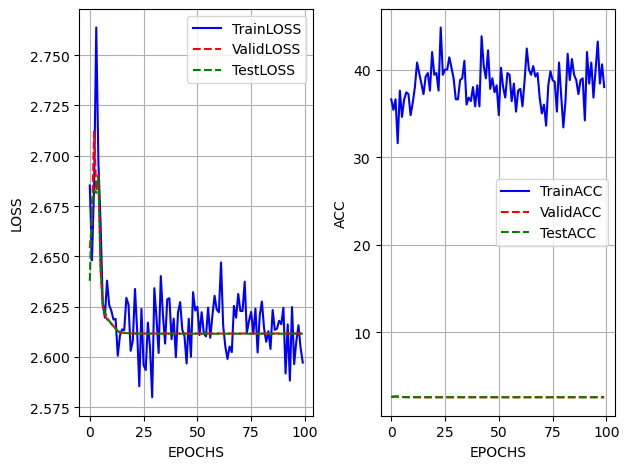

In [ ]:

# MODEL.eval()
# xdata = range(self.EPOCH)


fig, ax = plt.subplots(1,2)
ax = ax.flatten()
ax[0].plot(trainDF['loss'], 'b-', label='TrainLOSS')
ax[1].plot(trainDF['acc'], 'b-', label='TrainACC')

ax[0].plot(validDF['loss'], 'r--', label='ValidLOSS')
ax[1].plot(validDF['loss'], 'r--', label='ValidACC')

ax[0].plot(testDF['loss'], 'g--', label='TestLOSS')
ax[1].plot(testDF['loss'], 'g--', label='TestACC')


ax[0].grid()
ax[1].grid()
ax[0].legend()
ax[1].legend()
ax[0].set_xlabel('EPOCHS')
ax[1].set_xlabel('EPOCHS')

ax[0].set_ylabel('LOSS')
ax[1].set_ylabel('ACC')
plt.tight_layout()
plt.show()